In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML

from animations import animate_pendulum, animate_two_double_pendulums

# Simulating pendulums using constraint solver approach
Based on [the slides](https://box2d.org/files/ErinCatto_ModelingAndSolvingConstraints_GDC2009.pdf) by Erin Catto.

## Single (simple) pendulum
A simple pendulum consists of a dimensionless mass (a bob) attached to a wightless rod, as illustrated below.

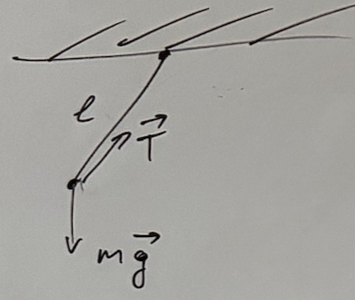


The differential equation that governs the motion of a simple pendulum is 
$$
\ddot\theta = -\frac{g}{l}\sin\theta.
$$

### Euler-Cramer

In [2]:
th0 = np.pi / 3
w0 = 0
dt = 0.01
g_val = 9.8
l = 0.5
t_span = np.arange(0, 7, step=dt)

th, w = th0, w0
th_history = np.zeros(len(t_span))
for i, t in enumerate(t_span):
    th_history[i] = th
    w = w - g_val / l * np.sin(th) * dt
    th = th + w * dt

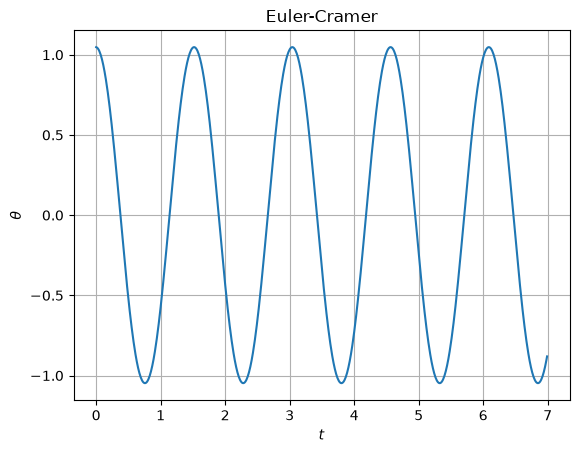

In [3]:
plt.grid()
plt.title('Euler-Cramer')
plt.ylabel(r'$\theta$')
plt.xlabel(r'$t$')
plt.plot(t_span, th_history)
plt.show()

In [4]:
x_history = l * np.sin(th_history)
y_history = -l * np.cos(th_history)

ani = animate_pendulum(x_history, y_history, l, t_span, dt)
plt.close()
HTML(ani.to_html5_video())

### Constraint solver
Let $\mathbf{x} = \begin{pmatrix} x \\ y \end{pmatrix}$ be the position of the bob.
Since the bob stays at a constant distance $l$ from the origin, we define the following constraint
$$C(\mathbf{x}) \equiv |\mathbf{x}| - l = 0.$$
The above condition is satisfied iff $\dot C = 0$ and $C(\mathbf{x}(0)) = 0$.
Using the chain rule we get
$$\frac{d}{dt} C(\mathbf{x}) = \frac{\partial C}{\partial x} \frac{dx}{dt} + \frac{\partial C}{\partial y} \frac{dy}{dt} = \left(\frac{\partial C}{\partial \mathbf{x}}\right)^T \frac{d\mathbf{x}}{dt} = 0.$$
Next, we work out the derivate of $C$ w.r.t. $\mathbf{x}$:
$$\frac{\partial C}{\partial x} = \frac{\partial}{\partial x}(|\mathbf{x}| - l) = \frac{\partial}{\partial x}\sqrt{x^2 + y^2} = \frac{x}{\sqrt{x^2 + y^2}}$$
$$\frac{\partial C}{\partial y} = \frac{y}{\sqrt{x^2 + y^2}}$$
$$\therefore \frac{\partial C}{\partial \mathbf{x}} = \frac{1}{\sqrt{x^2 + y^2}} \begin{pmatrix} x \\ y \end{pmatrix} = \frac{\mathbf{x}}{|\mathbf{x}|} \equiv J^T.$$
We can now write the constraint equation more compactly as $J\mathbf{v}=0$.

Newton's 2nd law applied to the bob of mass $m$ gives
$$m \ddot{\mathbf{x}} = m\mathbf{g} + \mathbf{T},$$
where $\mathbf{T}$ is the tension force in the rod.
We can rearrange this to get
$$\Delta \mathbf{v} = \frac{1}{m}(m\mathbf{g} + \mathbf{T})\Delta t = \mathbf{g}\Delta t + \frac{1}{m}\mathbf{T}\Delta t.$$
Now we observe that the tension force is acting along the rod and hence
$$\mathbf{T} = -\lambda \frac{\mathbf{x}}{|\mathbf{x}|} = -\lambda J^T,$$
where $\lambda$ is an unknown multiplier.
Substituting the expression for $\mathbf{T}$,
$$\Delta \mathbf{v} = \mathbf{g}\Delta t - \frac{1}{m}\lambda J^T \Delta t.$$

The update rule is therefore
$$\begin{cases} \mathbf{v}_{\text{pred}} = \mathbf{v}_0 + \mathbf{g}\Delta t \\ \mathbf{v}_1 = \mathbf{v}_{\text{pred}} - \frac{\Delta t}{m}\lambda J^T, \quad J\mathbf{v}_1 = 0. \end{cases}$$
The only step left is to eliminate $\lambda$. We do it by multiplying the eq. for $\mathbf{v}_1$ by $J$.
$$0 = J\mathbf{v}_1 = J\mathbf{v}_{\text{pred}} - \frac{\Delta t}{m}\lambda J J^T$$
$$\therefore 0 = J\mathbf{v}_{\text{pred}} - \frac{\Delta t}{m}\lambda \cdot 1 \implies \lambda = \frac{m}{\Delta t} J \mathbf{v}_{\text{pred}}.$$

The final algorithm is the following
$$\begin{cases} \mathbf{v}_{\text{pred}} = \mathbf{v}_0 + \mathbf{g}\Delta t \\ \mathbf{v}_1 = \mathbf{v}_{\text{pred}} - J \mathbf{v}_{\text{pred}} J^T. \end{cases}$$

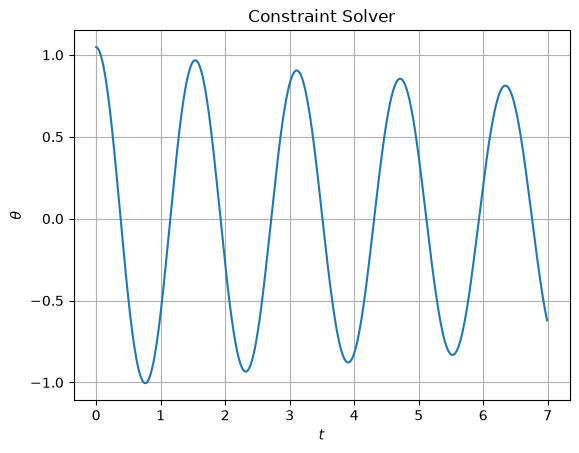

In [5]:
v = np.array([0, 0])
g = np.array([0, -g_val])
x = np.array([l * np.sin(th0), -l * np.cos(th0)])

x_history = np.zeros(shape=(len(t_span), 2))
l_history = np.zeros(len(t_span))
for i, t in enumerate(t_span):
    x_history[i] = x
    l_history[i] = np.linalg.norm(x)
    v_pred = v + g * dt
    J = x / np.linalg.norm(x)
    v_new = v_pred - np.dot(J, v_pred) * J

    v = v_new
    x = x + v * dt

th_history = np.atan2(x_history[:, 0], -x_history[:, 1])
plt.grid()
plt.title('Constraint Solver')
plt.ylabel(r'$\theta$')
plt.xlabel(r'$t$')
plt.plot(t_span, th_history)
plt.show()

The amplitude seems to decrease over time!
Let's investigate this further...

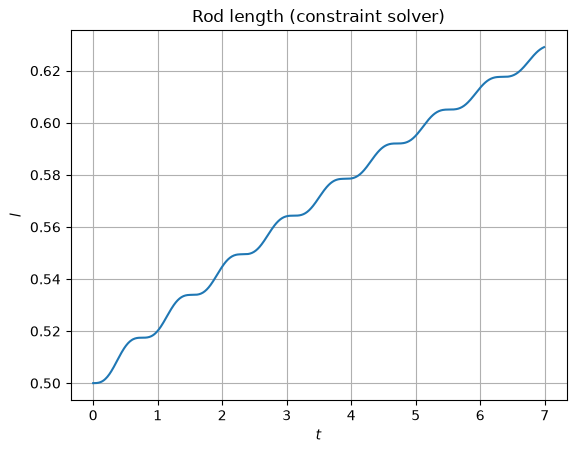

In [6]:
plt.grid()
plt.title('Rod length (constraint solver)')
plt.ylabel(r'$l$')
plt.xlabel(r'$t$')
plt.plot(t_span, l_history)
plt.show()

The rod is stretching out!

### Introducing Baumgarte stabilization
This technique mitigates the problem that we noticed earlier.

In [7]:
def get_C(x, l):
    return np.linalg.norm(x) - l

x_history = np.zeros(shape=(len(t_span), 2))
l_history = np.zeros(len(t_span))
beta = 0.2
for i, t in enumerate(t_span):
    x_history[i] = x
    l_history[i] = np.linalg.norm(x)
    v_pred = v + g * dt
    J = x / np.linalg.norm(x)
    C = get_C(x, l)
    bias = (beta / dt) * C
    v_new = v_pred - (np.dot(J, v_pred) + bias) * J

    v = v_new
    x = x + v * dt

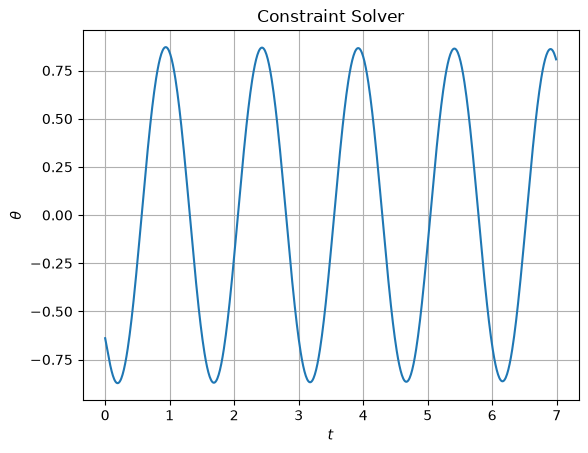

In [8]:
th_history = np.atan2(x_history[:, 0], -x_history[:, 1])
plt.grid()
plt.title('Constraint Solver')
plt.ylabel(r'$\theta$')
plt.xlabel(r'$t$')
plt.plot(t_span, th_history)
plt.show()

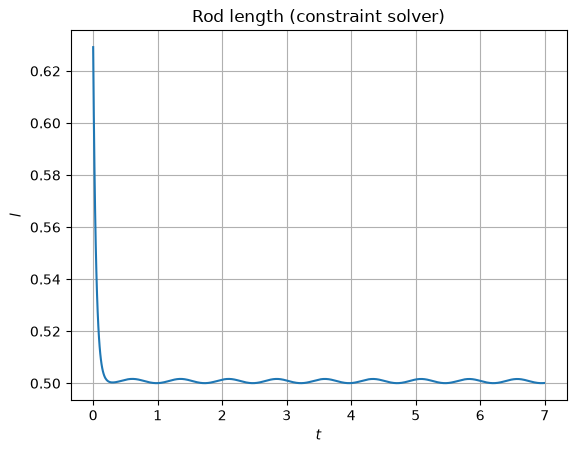

In [9]:
plt.grid()
plt.title('Rod length (constraint solver)')
plt.ylabel(r'$l$')
plt.xlabel(r'$t$')
plt.plot(t_span, l_history)
plt.show()

In [10]:
ani = animate_pendulum(x_history[:, 0], x_history[:, 1], l, t_span, dt)
plt.close()
HTML(ani.to_html5_video())

## Double pendulum
A double pendulum has two bobs instead of one, see the image below.

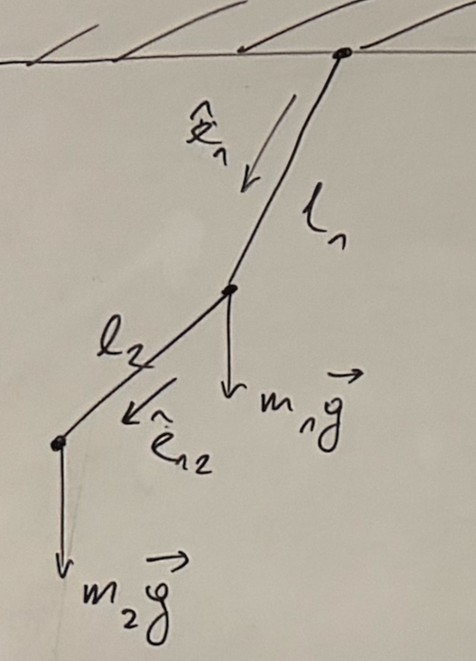

The equations of motion in this case are (see [this UMD website](https://physics.umd.edu/hep/drew/pendulum2.html))
$$
\begin{gather*}
Ml_1 \ddot\theta_1 + m_2l_2\ddot\theta_2\cos\Delta\theta + m_2l_2\dot\theta_2^2\sin\Delta\theta+Mg\sin\theta_1 = 0,\\
l_1\ddot\theta_1\cos\Delta\theta+l_2\ddot\theta_2-l_1\dot\theta_1^2\sin\Delta\theta + g\sin\theta_2 = 0,
\end{gather*}
$$
where $M=m_1+m_2$ and $\Delta\theta = \theta_1-\theta_2$.

### Euler-Cramer

In [11]:
l1, l2 = 1.5, 1
th1, th2 = np.pi / 4, np.pi / 3
w1, w2 = 0, -5
m1, m2 = 1, 0.5

th0 = np.array([th1, th2])
w0 = np.array([w1, w2])

def get_Ab(m1, l1, m2, l2, th, w, g):
    M = m1 + m2
    D = th[0] - th[1]

    A = np.array([
        [M * l1, m2 * l2 * np.cos(D)],
        [l1 * np.cos(D), l2]
    ])

    b = np.array([
        [-m2 * l2 * w[1]**2 * np.sin(D) - M * g * np.sin(th[0])],
        [l1 * w[0]**2 * np.sin(D) - g * np.sin(th[1])]
    ])

    return A, b

th, w = th0, w0
th_history = np.zeros((len(t_span), 2))
for i, t in enumerate(t_span):
    th_history[i, :] = th
    alpha = np.linalg.solve(*get_Ab(m1, l1, m2, l2, th, w, g_val)).flatten()
    w = w + alpha * dt
    th = th + w * dt

### Constraint solver
The algorithm for the double pendulum is derived similarly to the simple pendulum case we considered earlier.
Let $\mathbf{x}_1 = (x_1, y_1)^T$ be the position of bob \#1 and let $\mathbf{x}_2 = (x_2, y_2)^T$ be the position of bob \#2.
We also define the unit vectors $\text{let } \hat{e}_1 = \mathbf{x}_1/|\mathbf{x}_1|$ and $\hat{e}_2 = (\mathbf{x}_2 - \mathbf{x}_1)/|\mathbf{x}_2 - \mathbf{x}_1|$.
We have the following constrain equations
$$
\begin{gather*}
C_1(\mathbf{x}_1) \equiv |\mathbf{x}_1| - l_1 = 0\\
C_2(\mathbf{x}_1, \mathbf{x}_2) \equiv |\mathbf{x}_2 - \mathbf{x}_1| - l_2 = 0.
\end{gather*}
$$

This is equivalent to 
$$
\begin{gather*}
\frac{d}{dt} C_1(\mathbf{x}_1) = \left(\frac{\partial C_1}{\partial \mathbf{x}_1}\right)^T \frac{d\mathbf{x}_1}{dt} = \left(\frac{\mathbf{x}_1}{|\mathbf{x}_1|}\right)^T \mathbf{v}_1 = \hat{e}_1^T \mathbf{v}_1 = 0,\\
\frac{d}{dt} C_2(\mathbf{x}_1, \mathbf{x}_2) = \left(\frac{\partial C_2}{\partial \mathbf{x}}\right)^T \frac{d\mathbf{x}}{dt} = \begin{pmatrix} -\hat{e}_2 \\ \hat{e}_2 \end{pmatrix}^T \frac{d\mathbf{x}}{dt} = 0,
\end{gather*}$$
where $\mathbf{x} = \begin{pmatrix} \mathbf{x}_1\\ \mathbf{x}_2 \end{pmatrix}$, provided that the system satisfies $C_1 = 0$ and $C_2 = 0$ initially.
Let's gather the system's velocities into a single vector $\mathbf{v} = \begin{pmatrix} \mathbf{v}_1 \\ \mathbf{v}_2 \end{pmatrix}$.
Then we can rewrite the equations as
$$
\begin{gather*}
\frac{d}{dt} C_1(\mathbf{x}) = \hat{e}_1^T \mathbf{v}_1 = \begin{pmatrix} \hat{e}_1 \\ \mathbf{0} \end{pmatrix}^T \begin{pmatrix} \mathbf{v}_1 \\ \mathbf{v}_2 \end{pmatrix} = \begin{pmatrix} \hat{e}_1 \\ \mathbf{0} \end{pmatrix}^T \mathbf{v} = 0\\
\frac{d}{dt} C_2(\mathbf{x}) = \begin{pmatrix} -\hat{e}_2 \\ \hat{e}_2 \end{pmatrix}^T \mathbf{v} = 0.
\end{gather*}
$$
By introducing 
$$J = \begin{pmatrix} \hat{e}_1 & -\hat{e}_2 \\ \mathbf{0} & \hat{e}_2 \end{pmatrix}^T$$
we can combine these equations into
$$J \mathbf{v} = \mathbf{0}.$$

Newton's 2nd law gives
$$\begin{cases} m_1 \ddot{\mathbf{x}}_1 = m_1 \mathbf{g} + \mathbf{T}_1 - \mathbf{T}_2 \\ m_2 \ddot{\mathbf{x}}_2 = m_2 \mathbf{g} + \mathbf{T}_2 \end{cases} \iff M \dot{\mathbf{v}} = M \begin{pmatrix} \mathbf{g} \\ \mathbf{g} \end{pmatrix} + \begin{pmatrix} \mathbf{T}_1 - \mathbf{T}_2 \\ \mathbf{T}_2 \end{pmatrix},$$
where $\mathbf{T}_1 = \lambda_1 \hat{e}_1, \quad \mathbf{T}_2 = \lambda_2 \hat{e}_2 \quad M = \text{diag}(m_1, m_1, m_2, m_2)$.

By multiplying by $M^{-1}$ from the left, we get
$$\dot{\mathbf{v}} = \begin{pmatrix} \mathbf{g} \\ \mathbf{g} \end{pmatrix} + M^{-1} \begin{pmatrix} \lambda_1 \hat{e}_1 - \lambda_2 \hat{e}_2 \\ \lambda_2 \hat{e}_2 \end{pmatrix} = \begin{pmatrix} \mathbf{g} \\ \mathbf{g} \end{pmatrix} + M^{-1} J^T \mathbf{\lambda}, \quad \mathbf{\lambda} = \begin{pmatrix} \lambda_1 \\ \lambda_2 \end{pmatrix}.$$

$$\text{Alg.: } \begin{cases} \mathbf{v}_{\text{pred}} = \mathbf{v}_0 + \begin{pmatrix} \mathbf{g} \\ \mathbf{g} \end{pmatrix} \Delta t \\ \mathbf{v}_1 = \mathbf{v}_{\text{pred}} + M^{-1} J^T \mathbf{\lambda} \Delta t \end{cases}$$

Multiply the second equation by $J$ from the left to get
$$\mathbf{0} = J \mathbf{v}_{\text{pred}} + J M^{-1} J^T \mathbf{\lambda} \Delta t \implies \mathbf{\lambda} = -\frac{1}{\Delta t} (J M^{-1} J^T)^{-1} J \mathbf{v}_{\text{pred}}$$

$$\therefore \mathbf{v}_1 = \mathbf{v}_{\text{pred}} - M^{-1} J^T (J M^{-1} J^T)^{-1} J \mathbf{v}_{\text{pred}}$$

In [12]:
def get_x(l1, th1, l2, th2):
    x1 = l1 * np.array([np.sin(th1), -np.cos(th1)])
    x2 = x1 + l2 * np.array([np.sin(th2), -np.cos(th2)])
    return np.vstack((x1, x2))

def get_v(l1, th1, w1, l2, th2, w2):
    v1 = w1 * l1 * np.array([np.cos(th1), np.sin(th1)])
    v2 = v1 + w2 * l2 * np.array([np.cos(th2), np.sin(th2)])
    return np.vstack((v1, v2))

def get_J(x):
    x1 = x[0:2, :]
    x2 = x[2:4, :]

    e1 = x1 / np.linalg.norm(x1)
    e12 = (x2 - x1) / np.linalg.norm(x2 - x1)
    zeros = np.zeros((1, 2))
    row1 = np.hstack((e1.T, zeros))
    row2 = np.hstack((-e12.T, e12.T)) # reversed signs

    J = np.vstack((row1, row2))
    return J

def get_M(m1, m2):
    return np.diag([m1, m1, m2, m2])

def get_C(x, l1, l2):
    x1 = x[0:2, :]
    x2 = x[2:4, :]
    c1 = np.linalg.norm(x1) - l1
    c2 = np.linalg.norm(x2 - x1) - l2
    return np.array([[c1], [c2]])

The code below already incorporates the Baumgarte stabilization.

In [13]:
v = get_v(l1, th1, w1, l2, th2, w2).reshape(4, 1)
g = np.array([0, -g_val, 0, -g_val]).reshape(4, 1)

x = get_x(l1=l1, th1=th1, l2=l2, th2=th2).reshape(4, 1)

M = get_M(m1=m1, m2=m2)
M_inv = np.linalg.inv(M)
beta = 0.2

x_history = np.zeros(shape=(4, len(t_span)))
l1_history = np.zeros(len(t_span))
l2_history = np.zeros((len(t_span)))
for i, t in enumerate(t_span):
    x_history[:, i:i+1] = x
    l1_history[i] = np.linalg.norm(x[0:2])
    l2_history[i] = np.linalg.norm(x[2:4] - x[0:2])

    v_pred = v + g * dt
    J = get_J(x)
    C = get_C(x, l1, l2)
    bias = (beta / dt) * C
    M_inv = np.linalg.inv(M)
    S = np.linalg.inv(J @ M_inv @ J.T)
    v_new = v_pred - M_inv @ J.T @ S @ (J @ v_pred + bias)

    v = v_new
    x = x + v * dt

Let's verify that the rods don't stretch.

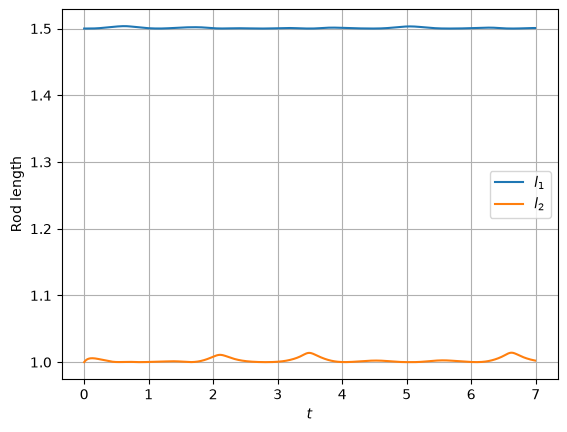

In [14]:
plt.grid()
plt.ylabel('Rod length')
plt.xlabel(r'$t$')
plt.plot(t_span, l1_history, label=r'$l_1$')
plt.plot(t_span, l2_history, label=r'$l_2$')
plt.legend(loc='best')
plt.show()

Even though both systems are identical and initialized in the same way, inaccuracies of both methods cause the paths of the pendulums to eventually diverge.

In [15]:
ani = animate_two_double_pendulums(get_x(l1, th_history[:, 0], l2, th_history[:, 1]), x_history,
                                   l1, l2, dt, t_span, "Euler-Cramer", "Constrain Solver")

plt.close()
HTML(ani.to_html5_video())

## Generalizing to an arbitrary number of bobs
If you stare at the derivation for the double pendulum case long enough, you can come up with a general form of $J$ for the pendulum consisting of $n$ bobs.
There are $n$ distance constraints, so $J$ is an $n \times 2n$ block-bidiagonal matrix:

$$J = \begin{pmatrix} \hat{e}_1^T & 0^T & 0^T & \dots & 0^T & 0^T \\ -\hat{e}_2^T & \hat{e}_2^T & 0^T & \dots & 0^T & 0^T \\ 0^T & -\hat{e}_3^T & \hat{e}_3^T & \dots & 0^T & 0^T \\ \vdots & \vdots & \ddots & \ddots & \vdots & \vdots \\ 0^T & 0^T & \dots & 0^T & -\hat{e}_n^T & \hat{e}_n^T \end{pmatrix}_{n \times 2n}$$
* Row 1 acts only on $v_1$.
* Row $i$ (for $i \ge 2$) acts on $v_{i-1}$ with $-\hat{e}_i^T$ and on $v_i$ with $+\hat{e}_i^T$.
In the general case, the position and velocity are given by $\mathbf{x} = (x_1, x_2, \ldots, x_n)^T \in \mathbb{R}^{2n}, \mathbf{v} = (v_1, v_2, \ldots, v_n)^T \in \mathbb{R}^{2n}$; we also need the unit vectors $\hat{e}_i$ along rod $i$ (pointing from bob $i - 1$ to bob $i$):
$$\hat{e}_1 = \frac{x_1 - x_0}{\vert{}x_1 - x_0\vert{}}, \quad \hat{e}_i = \frac{x_i - x_{i-1}}{\vert{}x_i - x_{i-1}\vert{}} \quad \text{for } i = 2, \ldots, n$$

In [16]:
def get_J(x: np.ndarray) -> np.ndarray:
    n = x.shape[0] // 2
    pts = x.reshape(n, 2)

    es = []
    es.append(pts[0] / np.linalg.norm(pts[0]))
    for i in range(1, n):
        diff = pts[i] - pts[i - 1]
        es.append(diff / np.linalg.norm(diff))

    J = np.zeros((n, 2 * n))

    J[0, 0:2] = es[0]

    for i in range(1, n):
        J[i, 2 * (i - 1) : 2 * i] = -es[i]  # -e_i^T on v_{i-1}
        J[i, 2 * i : 2 * (i + 1)] = es[i]  # +e_i^T on v_i

    return J


def get_M(ms: list[float]) -> np.ndarray:
    return np.diag(np.repeat(ms, 2))


def get_inv_M(ms: list[float]) -> np.ndarray:
    return np.diag(np.repeat(1.0 / np.array(ms), 2))


def get_C(x: np.ndarray, ls: list[float]) -> np.ndarray:
    n = len(ls)
    pts = x.reshape(n, 2)

    C = np.zeros((n, 1))
    C[0] = np.linalg.norm(pts[0]) - ls[0]

    for i in range(1, n):
        C[i] = np.linalg.norm(pts[i] - pts[i - 1]) - ls[i]

    return C

def get_x(ls: list[float], ths: list[float]) -> np.ndarray:
    n = len(ls)
    ls = np.array(ls)
    ths = np.array(ths)

    dx = ls * np.sin(ths)
    dy = -ls * np.cos(ths)

    x_coords = np.cumsum(dx)
    y_coords = np.cumsum(dy)

    pts = np.column_stack((x_coords, y_coords))
    return pts.reshape(2 * n, 1)


def get_v(ls: list[float], ths: list[float], ws: list[float]) -> np.ndarray:
    n = len(ls)
    ls = np.array(ls)
    ths = np.array(ths)
    ws = np.array(ws)

    dvx = ws * ls * np.cos(ths)
    dvy = ws * ls * np.sin(ths)

    vx_coords = np.cumsum(dvx)
    vy_coords = np.cumsum(dvy)

    vels = np.column_stack((vx_coords, vy_coords))
    return vels.reshape(2 * n, 1)

In [17]:
n = 10
g = np.array([0, -g_val] * n).reshape(2 * n, 1)
ls = [1] * n
ms = [1] * n
ths = [np.pi / 6 + np.pi * i / (4 * n) for i in range(n)]
ws = [0] * n

x = get_x(ls, ths)
v = get_v(ls, ths, ws)
M = get_M(ms)
M_inv = get_inv_M(ms)
beta = 0.2

x_history = np.zeros(shape=(2 * n, len(t_span)))
for i, t in enumerate(t_span):
    x_history[:, i:i+1] = x

    v_pred = v + g * dt
    J = get_J(x)
    C = get_C(x, ls)
    bias = (beta / dt) * C
    S = np.linalg.inv(J @ M_inv @ J.T)
    v_new = v_pred - M_inv @ J.T @ S @ (J @ v_pred + bias)

    v = v_new
    x = x + v * dt

In [18]:
from animations import animate_n_pendulum

ani = animate_n_pendulum(x_history, ls, dt, t_span)
plt.close()
HTML(ani.to_html5_video())